In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!cp -r "/content/drive/MyDrive/stuff_model/data/" "/content/"

In [3]:
!cp -r "/content/drive/MyDrive/stuff_model/model_storage/" "/content/"

In [4]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.metrics import root_mean_squared_error
import joblib

from scipy.stats import zscore
from scipy import stats
from tqdm.notebook import tqdm

In [5]:
%matplotlib inline

In [6]:
# Pitch category routing — must match stuff_model_separated.ipynb
PITCH_CATEGORIES = {
    'Fastball':     ['FF', 'SI', 'FC', 'FA'],
    'BreakingBall': ['SL', 'ST', 'CU', 'KC', 'SV'],
    'Offspeed':     ['CH', 'FS', 'FO'],
}

# Load the three separated LightGBM models
models = {
    'Fastball':     joblib.load('./model_storage/lgb_fastball_model.joblib'),
    'BreakingBall': joblib.load('./model_storage/lgb_breakingball_model.joblib'),
    'Offspeed':     joblib.load('./model_storage/lgb_offspeed_model.joblib'),
}

# Load unified scaling reference (computed from all training predictions pooled)
scaler = joblib.load('./model_storage/stuff_plus_separated_scaler.joblib')
train_ref_mean = scaler['ref_mean']
train_ref_std  = scaler['ref_std']

print('Models loaded:', list(models.keys()))
print(f'Training scale reference: mean={train_ref_mean:.6f}, std={train_ref_std:.6f}')

Models loaded: ['Fastball', 'BreakingBall', 'Offspeed']
Training scale reference: mean=-0.000027, std=0.024884


In [7]:
def calculate_stuff_plus(df, ref_mean, ref_std):
    """Scale model predictions to the 20-80 scouting scale."""
    z_scores   = (df['y_pred'].values - ref_mean) / ref_std
    stuff_plus = np.clip(50 - z_scores * 10, 20, 80)
    df = df.copy()
    df['stuff_plus'] = stuff_plus
    return df

In [8]:
# Load 2025 test data
data_2025 = pl.read_csv('./data/test_data_2025.csv')

# Convert categorical columns
data_2025 = data_2025.with_columns([
    pl.col('p_throws').cast(pl.Categorical),
    pl.col('stand').cast(pl.Categorical),
])

# 19 features — must match stuff_model_separated.ipynb
features = [
    'release_speed',
    'release_spin_rate',
    'spin_axis',
    'release_extension',
    'az',
    'ax',
    'release_pos_x',
    'release_pos_z',
    'speed_diff',
    'az_diff',
    'ax_diff',
    'stand',
    'p_throws',
    'VAA',
    'HAA',
    'vaa_diff',
    'ssw_x',
    'ssw_z',
    'ssw_magnitude',
]

categorical_cols = ['p_throws', 'stand']

# Drop nulls and convert to pandas
data_2025 = data_2025.drop_nulls(subset=features)
data_2025 = data_2025.to_pandas()

for col in categorical_cols:
    data_2025[col] = data_2025[col].astype('category')

print(f'Loaded {len(data_2025):,} pitches from 2025')
print(f'Date range: {data_2025["game_date"].min()} to {data_2025["game_date"].max()}')
print(f'Features: {len(features)}')

Loaded 725,982 pitches from 2025
Date range: 2025-03-18 to 2025-09-28
Features: 19


In [9]:
# Route each pitch to its category model and generate predictions
data_2025['y_pred'] = np.nan

for category, pitch_types in PITCH_CATEGORIES.items():
    mask = data_2025['pitch_type'].isin(pitch_types)
    if mask.sum() > 0:
        data_2025.loc[mask, 'y_pred'] = models[category].predict(data_2025.loc[mask, features])
        print(f'{category:15s}: {mask.sum():>7,} predictions')

unmatched = data_2025['y_pred'].isna().sum()
if unmatched > 0:
    print(f'Warning: {unmatched:,} pitches had no matching category — dropping')
    data_2025 = data_2025.dropna(subset=['y_pred'])

# Re-center on 2025 league average while preserving the training spread
# This makes 50 = 2025 average; using train_ref_std keeps the scale calibrated
ref_mean_2025 = data_2025['y_pred'].mean()
print(f'\n2025 raw prediction mean: {ref_mean_2025:.6f}  (train ref: {train_ref_mean:.6f})')
print(f'Using training ref_std={train_ref_std:.6f} to preserve calibrated spread')

data_2025 = calculate_stuff_plus(data_2025, ref_mean=ref_mean_2025, ref_std=train_ref_std)

print(f'\nTotal predictions: {len(data_2025):,}')
print(f'Stuff+ range: {data_2025["stuff_plus"].min():.1f} – {data_2025["stuff_plus"].max():.1f}')
print(f'Stuff+ mean:  {data_2025["stuff_plus"].mean():.2f}')
print(f'Stuff+ std:   {data_2025["stuff_plus"].std():.2f}')

Fastball       : 401,758 predictions
BreakingBall   : 225,411 predictions
Offspeed       :  98,813 predictions

2025 raw prediction mean: -0.001768  (train ref: -0.000027)
Using training ref_std=0.024884 to preserve calibrated spread

Total predictions: 725,982
Stuff+ range: 20.0 – 80.0
Stuff+ mean:  50.10
Stuff+ std:   9.30


In [10]:
# Helper function to determine pitcher role (SP vs RP)
# We'll use a simple heuristic: if a pitcher averages <2 innings per game, they're a reliever
def classify_pitcher_role(df):
    """
    Classify pitchers as SP (Starting Pitcher) or RP (Relief Pitcher)
    Based on average pitches per game appearance
    """
    pitcher_stats = df.groupby('pitcher').agg(
        total_pitches=('pitch_type', 'count'),
        total_games=('game_date', 'nunique'),
        player_name=('player_name', 'first')
    ).reset_index()

    pitcher_stats['pitches_per_game'] = pitcher_stats['total_pitches'] / pitcher_stats['total_games']

    # Threshold: SPs typically throw 80+ pitches per game, RPs throw fewer
    # Using 60 as a reasonable cutoff
    pitcher_stats['role'] = pitcher_stats['pitches_per_game'].apply(
        lambda x: 'SP' if x >= 60 else 'RP'
    )

    return pitcher_stats[['pitcher', 'player_name', 'role']]

# Classify pitchers
pitcher_roles = classify_pitcher_role(data_2025)

# Merge role back to main dataframe
data_2025 = data_2025.merge(pitcher_roles[['pitcher', 'role']], on='pitcher', how='left')

print("Pitcher role distribution:")
print(pitcher_roles['role'].value_counts())
print(f"\nSample SP pitchers:")
print(pitcher_roles[pitcher_roles['role'] == 'SP']['player_name'].head(10).tolist())
print(f"\nSample RP pitchers:")
print(pitcher_roles[pitcher_roles['role'] == 'RP']['player_name'].head(10).tolist())

Pitcher role distribution:
role
RP    780
SP    251
Name: count, dtype: int64

Sample SP pitchers:
['Verlander, Justin', 'Hill, Rich', 'Morton, Charlie', 'Scherzer, Max', 'Carrasco, Carlos', 'Kershaw, Clayton', 'Miley, Wade', 'Quintana, Jose', 'Gibson, Kyle', 'Darvish, Yu']

Sample RP pitchers:
['Jansen, Kenley', 'Chavez, Jesse', 'Martin, Chris', 'Wilson, Justin', 'García, Luis', 'Stock, Robert', 'Yates, Kirby', 'Ottavino, Adam', 'Rojas, Miguel', 'Robertson, David']


In [11]:
## Starting Pitcher (SP) Leaderboard

# Filter for starting pitchers with minimum 200 pitches
min_pitches = 200

sp_data = data_2025[data_2025['role'] == 'SP']

sp_leaderboard = sp_data.groupby(['pitcher', 'player_name']).agg(
    avg_stuff_plus=('stuff_plus', 'mean'),
    pitches=('stuff_plus', 'count')
).reset_index()

# Filter by minimum pitches
sp_leaderboard = sp_leaderboard[sp_leaderboard['pitches'] >= min_pitches]

# Sort by Stuff+
sp_leaderboard = sp_leaderboard.sort_values('avg_stuff_plus', ascending=False).reset_index(drop=True)

# Add rank
sp_leaderboard['rank'] = range(1, len(sp_leaderboard) + 1)

print("=" * 70)
print("TOP 20 STARTING PITCHERS - 2025 STUFF+ LEADERBOARD")
print("=" * 70)
print(f"(Minimum {min_pitches} pitches)")
print()
print(sp_leaderboard[['rank', 'player_name', 'avg_stuff_plus', 'pitches']].head(20).to_string(index=False))
print()
print(f"Total qualified SPs: {len(sp_leaderboard)}")

TOP 20 STARTING PITCHERS - 2025 STUFF+ LEADERBOARD
(Minimum 200 pitches)

 rank            player_name  avg_stuff_plus  pitches
    1         Greene, Hunter       53.999666     1832
    2        Valdez, Framber       53.768526     2977
    3          deGrom, Jacob       53.620207     2741
    4    Sánchez, Cristopher       52.843013     2955
    5          Skubal, Tarik       52.800969     2849
    6 Schwellenbach, Spencer       52.712163     1651
    7          Wheeler, Zack       52.651601     2461
    8           Ragans, Cole       52.486668     1079
    9        Chandler, Bubba       52.415887      395
   10          McLean, Nolan       52.331854      739
   11         Burnes, Corbin       52.145269     1009
   12     Misiorowski, Jacob       51.910306     1164
   13            Webb, Logan       51.894242     3282
   14          Kirby, George       51.802961     2086
   15         Fitts, Richard       51.714362      735
   16        Rasmussen, Drew       51.679914     2316
   17   

In [12]:
## Relief Pitcher (RP) Leaderboard

# Filter for relief pitchers with minimum 100 pitches (RPs throw less)
min_pitches_rp = 100

rp_data = data_2025[data_2025['role'] == 'RP']

rp_leaderboard = rp_data.groupby(['pitcher', 'player_name']).agg(
    avg_stuff_plus=('stuff_plus', 'mean'),
    pitches=('stuff_plus', 'count')
).reset_index()

# Filter by minimum pitches
rp_leaderboard = rp_leaderboard[rp_leaderboard['pitches'] >= min_pitches_rp]

# Sort by Stuff+
rp_leaderboard = rp_leaderboard.sort_values('avg_stuff_plus', ascending=False).reset_index(drop=True)

# Add rank
rp_leaderboard['rank'] = range(1, len(rp_leaderboard) + 1)

print("=" * 70)
print("TOP 20 RELIEF PITCHERS - 2025 STUFF+ LEADERBOARD")
print("=" * 70)
print(f"(Minimum {min_pitches_rp} pitches)")
print()
print(rp_leaderboard[['rank', 'player_name', 'avg_stuff_plus', 'pitches']].head(20).to_string(index=False))
print()
print(f"Total qualified RPs: {len(rp_leaderboard)}")

TOP 20 RELIEF PITCHERS - 2025 STUFF+ LEADERBOARD
(Minimum 100 pitches)

 rank       player_name  avg_stuff_plus  pitches
    1    Megill, Trevor       54.952667      774
    2   Clase, Emmanuel       54.886443      775
    3     Helsley, Ryan       54.402310     1012
    4      Jax, Griffin       54.273669     1124
    5      Burns, Chase       54.247796      764
    6 Estrada, Jeremiah       54.217549     1251
    7  Rodríguez, Randy       54.189068      859
    8   Morejon, Adrian       53.992542     1032
    9      Ashby, Aaron       53.921628     1033
   10     Taylor, Grant       53.848947      610
   11     Scott, Tanner       53.785550      924
   12    Suarez, Robert       53.674222     1091
   13 Montgomery, Mason       53.668609      876
   14       Brash, Matt       53.581778      819
   15   Williams, Devin       53.432661     1146
   16  Kerkering, Orion       53.257531     1121
   17     Rogers, Tyler       53.155519      991
   18  Robertson, David       53.153111      3

In [13]:
## Individual Pitch Leaderboard (e.g., Fastballs, Skubal's Fastball)

# Minimum pitches for individual pitch type analysis
min_pitch_count = 50

# Create pitch-level leaderboard (pitcher + pitch_type)
pitch_leaderboard = data_2025.groupby(['pitcher', 'player_name', 'pitch_type']).agg(
    avg_stuff_plus=('stuff_plus', 'mean'),
    pitches=('stuff_plus', 'count')
).reset_index()

# Filter by minimum pitches
pitch_leaderboard = pitch_leaderboard[pitch_leaderboard['pitches'] >= min_pitch_count]

# Sort by Stuff+
pitch_leaderboard = pitch_leaderboard.sort_values('avg_stuff_plus', ascending=False).reset_index(drop=True)

# Add rank
pitch_leaderboard['rank'] = range(1, len(pitch_leaderboard) + 1)

print("=" * 80)
print("TOP 20 INDIVIDUAL PITCHES - 2025 STUFF+ LEADERBOARD")
print("=" * 80)
print(f"(Minimum {min_pitch_count} pitches of that type)")
print()
print(pitch_leaderboard[['rank', 'player_name', 'pitch_type', 'avg_stuff_plus', 'pitches']].head(20).to_string(index=False))
print()
print(f"Total qualified pitch-type combinations: {len(pitch_leaderboard)}")

TOP 20 INDIVIDUAL PITCHES - 2025 STUFF+ LEADERBOARD
(Minimum 50 pitches of that type)

 rank       player_name pitch_type  avg_stuff_plus  pitches
    1      Skenes, Paul         FS       57.904222      417
    2      Miller, Erik         SI       57.209800       92
    3      Ashby, Aaron         CU       56.917926      273
    4      Jax, Griffin         ST       56.884426      490
    5      García, Yimi         ST       56.838491       64
    6     Helsley, Ryan         SL       56.550988      475
    7   Thielbar, Caleb         SL       56.341661      123
    8 Estrada, Jeremiah         FF       56.130042      710
    9    Megill, Trevor         KC       55.933642      305
   10     Taylor, Grant         CU       55.767763      132
   11     Peguero, Joel         SL       55.718211      107
   12   Devenski, Chris         CH       55.714378      109
   13   Fisher, Braydon         SL       55.710255      319
   14     deGrom, Jacob         SL       55.648172     1029
   15     Hol

In [14]:
## Pitch Type Leaderboards

# Create leaderboards for major pitch types
pitch_types = ['FF', 'SL', 'CH', 'CU', 'SI', 'FC']
min_pitch_count = 50

for pt in pitch_types:
    pt_data = pitch_leaderboard[pitch_leaderboard['pitch_type'] == pt].copy()

    if len(pt_data) > 0:
        # Add percentile
        pt_data['percentile'] = pt_data['avg_stuff_plus'].rank(pct=True) * 100

        print("=" * 80)
        if pt == 'FF':
            print(f"TOP 15 FOUR-SEAM FASTBALLS - 2025 STUFF+ LEADERBOARD")
        elif pt == 'SL':
            print(f"TOP 15 SLIDERS - 2025 STUFF+ LEADERBOARD")
        elif pt == 'CH':
            print(f"TOP 15 CHANGEUPS - 2025 STUFF+ LEADERBOARD")
        elif pt == 'CU':
            print(f"TOP 15 CURVEBALLS - 2025 STUFF+ LEADERBOARD")
        elif pt == 'SI':
            print(f"TOP 15 SINKERS - 2025 STUFF+ LEADERBOARD")
        elif pt == 'FC':
            print(f"TOP 15 CUTTERS - 2025 STUFF+ LEADERBOARD")
        print("=" * 80)
        print(f"(Minimum {min_pitch_count} pitches)")
        print()
        print(pt_data[['rank', 'player_name', 'avg_stuff_plus', 'pitches']].head(15).to_string(index=False))
        print()
        print(f"Total qualified pitchers: {len(pt_data)}")
        print()

TOP 15 FOUR-SEAM FASTBALLS - 2025 STUFF+ LEADERBOARD
(Minimum 50 pitches)

 rank            player_name  avg_stuff_plus  pitches
    8      Estrada, Jeremiah       56.130042      710
   35     Misiorowski, Jacob       54.898196      642
   40       Chapman, Aroldis       54.760334      369
   53       Henriquez, Ronny       54.487935      344
   57         Greene, Hunter       54.388656      986
   59         Megill, Trevor       54.314719      469
   76           Burns, Chase       54.101187      442
   92         Stewart, Brock       53.932957      322
   96          Wheeler, Zack       53.903374     1009
   98            Pérez, Eury       53.893411      859
  101 Schwellenbach, Spencer       53.853743      577
  105       Rodríguez, Randy       53.792686      484
  108      Montgomery, Mason       53.762625      583
  136           Ragans, Cole       53.401821      534
  138              Puk, A.J.       53.375962      112

Total qualified pitchers: 607

TOP 15 SLIDERS - 2025 STUFF+ 

In [15]:
## Splitter (FS) Analysis

# Filter for splitters
splitter_data = data_2025[data_2025['pitch_type'] == 'FS']

print("=" * 80)
print("SPLITTER (FS) ANALYSIS - 2025")
print("=" * 80)
print()

if len(splitter_data) > 0:
    print(f"Total splitters thrown: {len(splitter_data):,}")
    print(f"Average Stuff+: {splitter_data['stuff_plus'].mean():.2f}")
    print(f"Std Dev: {splitter_data['stuff_plus'].std():.2f}")
    print(f"Min Stuff+: {splitter_data['stuff_plus'].min():.2f}")
    print(f"Max Stuff+: {splitter_data['stuff_plus'].max():.2f}")
    print()

    # Get splitter leaderboard
    min_splitter_count = 30  # Lower threshold since splitters are less common

    splitter_leaderboard = splitter_data.groupby(['pitcher', 'player_name']).agg(
        avg_stuff_plus=('stuff_plus', 'mean'),
        pitches=('stuff_plus', 'count')
    ).reset_index()

    splitter_leaderboard = splitter_leaderboard[splitter_leaderboard['pitches'] >= min_splitter_count]
    splitter_leaderboard = splitter_leaderboard.sort_values('avg_stuff_plus', ascending=False).reset_index(drop=True)
    splitter_leaderboard['rank'] = range(1, len(splitter_leaderboard) + 1)

    print("=" * 80)
    print(f"TOP 20 SPLITTERS - 2025 STUFF+ LEADERBOARD")
    print("=" * 80)
    print(f"(Minimum {min_splitter_count} pitches)")
    print()
    print(splitter_leaderboard[['rank', 'player_name', 'avg_stuff_plus', 'pitches']].head(20).to_string(index=False))
    print()
    print(f"Total qualified pitchers: {len(splitter_leaderboard)}")
    print()

    # Compare splitter to other pitch types
    print("=" * 80)
    print("SPLITTER EFFECTIVENESS COMPARISON")
    print("=" * 80)
    print()

    pitch_comparison = data_2025.groupby('pitch_type').agg(
        avg_stuff_plus=('stuff_plus', 'mean'),
        pitches=('stuff_plus', 'count')
    ).sort_values('avg_stuff_plus', ascending=False).reset_index()

    pitch_comparison['rank'] = range(1, len(pitch_comparison) + 1)

    print("Average Stuff+ by Pitch Type:")
    print(pitch_comparison.to_string(index=False))
    print()

    splitter_rank = pitch_comparison[pitch_comparison['pitch_type'] == 'FS']['rank'].values
    if len(splitter_rank) > 0:
        print(f"Splitter ranks #{splitter_rank[0]} out of {len(pitch_comparison)} pitch types by average Stuff+")
else:
    print("No splitters found in 2025 data")

SPLITTER (FS) ANALYSIS - 2025

Total splitters thrown: 23,499
Average Stuff+: 50.22
Std Dev: 10.60
Min Stuff+: 20.00
Max Stuff+: 78.12

TOP 20 SPLITTERS - 2025 STUFF+ LEADERBOARD
(Minimum 30 pitches)

 rank            player_name  avg_stuff_plus  pitches
    1           Skenes, Paul       57.904222      417
    2          Holman, Grant       55.633896      146
    3           Winn, Keaton       54.907431       94
    4 Schwellenbach, Spencer       54.755604      228
    5          Bednar, David       54.608360      206
    6         Finnegan, Kyle       53.856943      314
    7    Yamamoto, Yoshinobu       53.831228      710
    8        Arias, Luarbert       53.717906       33
    9          Cano, Yennier       53.434513       71
   10         Kriske, Brooks       53.253592      204
   11         Yesavage, Trey       53.131926       63
   12            Sands, Cole       53.052892      250
   13         Blewett, Scott       52.876999      145
   14        Halvorsen, Seth       52.79116

In [16]:
## Sweeper (ST) Analysis

# Filter for sweepers
sweeper_data = data_2025[data_2025['pitch_type'] == 'ST']

print("=" * 80)
print("SWEEPER (ST) ANALYSIS - 2025")
print("=" * 80)
print()

if len(sweeper_data) > 0:
    print(f"Total sweepers thrown: {len(sweeper_data):,}")
    print(f"Average Stuff+: {sweeper_data['stuff_plus'].mean():.2f}")
    print(f"Std Dev: {sweeper_data['stuff_plus'].std():.2f}")
    print(f"Min Stuff+: {sweeper_data['stuff_plus'].min():.2f}")
    print(f"Max Stuff+: {sweeper_data['stuff_plus'].max():.2f}")
    print()

    # Get sweeper leaderboard
    min_sweeper_count = 30  # Lower threshold since sweepers are less common

    sweeper_leaderboard = sweeper_data.groupby(['pitcher', 'player_name']).agg(
        avg_stuff_plus=('stuff_plus', 'mean'),
        pitches=('stuff_plus', 'count')
    ).reset_index()

    sweeper_leaderboard = sweeper_leaderboard[sweeper_leaderboard['pitches'] >= min_sweeper_count]
    sweeper_leaderboard = sweeper_leaderboard.sort_values('avg_stuff_plus', ascending=False).reset_index(drop=True)
    sweeper_leaderboard['rank'] = range(1, len(sweeper_leaderboard) + 1)

    print("=" * 80)
    print(f"TOP 20 SWEEPERS - 2025 STUFF+ LEADERBOARD")
    print("=" * 80)
    print(f"(Minimum {min_sweeper_count} pitches)")
    print()
    print(sweeper_leaderboard[['rank', 'player_name', 'avg_stuff_plus', 'pitches']].head(20).to_string(index=False))
    print()
    print(f"Total qualified pitchers: {len(sweeper_leaderboard)}")
    print()

    # Compare sweeper to other pitch types
    print("=" * 80)
    print("SWEEPER EFFECTIVENESS COMPARISON")
    print("=" * 80)
    print()

    pitch_comparison = data_2025.groupby('pitch_type').agg(
        avg_stuff_plus=('stuff_plus', 'mean'),
        pitches=('stuff_plus', 'count')
    ).sort_values('avg_stuff_plus', ascending=False).reset_index()

    pitch_comparison['rank'] = range(1, len(pitch_comparison) + 1)

    print("Average Stuff+ by Pitch Type:")
    print(pitch_comparison.to_string(index=False))
    print()

    sweeper_rank = pitch_comparison[pitch_comparison['pitch_type'] == 'ST']['rank'].values
    if len(sweeper_rank) > 0:
        print(f"Sweeper ranks #{sweeper_rank[0]} out of {len(pitch_comparison)} pitch types by average Stuff+")
else:
    print("No sweepers found in 2025 data")

SWEEPER (ST) ANALYSIS - 2025

Total sweepers thrown: 52,846
Average Stuff+: 51.02
Std Dev: 7.84
Min Stuff+: 20.00
Max Stuff+: 72.46

TOP 20 SWEEPERS - 2025 STUFF+ LEADERBOARD
(Minimum 30 pitches)

 rank      player_name  avg_stuff_plus  pitches
    1     Jax, Griffin       56.884426      490
    2     García, Yimi       56.838491       64
    3 Kerkering, Orion       55.343051      539
    4      Leahy, Kyle       55.090925      187
    5       Bird, Jake       54.914511      406
    6     Zuber, Tyler       54.802769       84
    7   Phillips, Evan       54.794135       49
    8    Hodge, Porter       54.754758      199
    9   Ohtani, Shohei       54.701341      172
   10     Warren, Will       54.700167      593
   11  Schlittler, Cam       54.653505       39
   12   Treinen, Blake       54.272324      241
   13    Perkins, Jack       54.242292      209
   14    Morales, Luis       54.171735      218
   15      Kelly, Zack       54.150693      120
   16   Casparius, Ben       54.091

Plotting 10 pitch types with 1000+ pitches
Pitch types: ['FF', 'SI', 'SL', 'CH', 'FC', 'ST', 'CU', 'FS', 'KC', 'SV']



/tmp/ipykernel_3137/1434918654.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(pitch_type_stuff, labels=sorted_pitch_types, patch_artist=True)


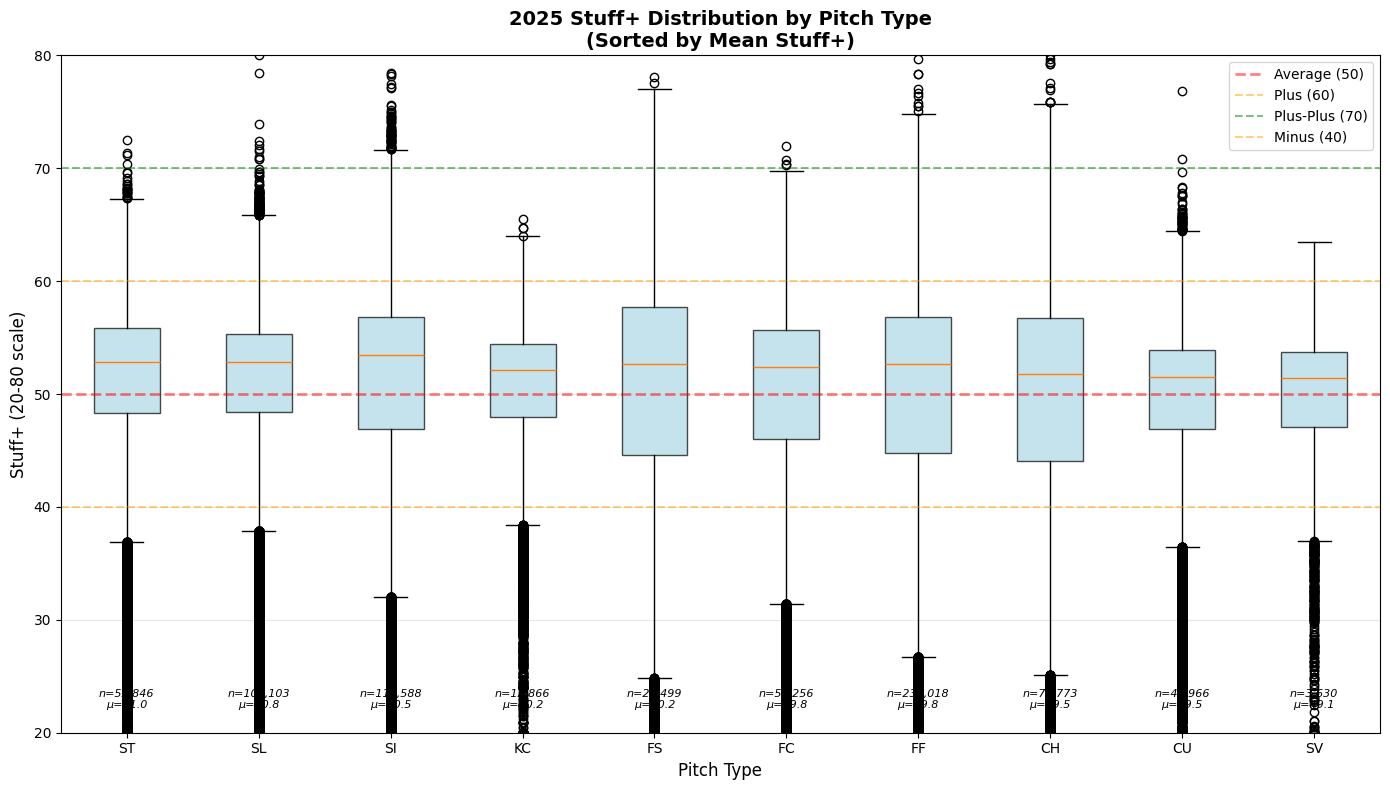


PITCH TYPE SUMMARY STATISTICS

            mean_stuff  median_stuff  std_stuff   count
pitch_type                                             
FO           51.755032     53.060110   9.013705     541
ST           51.018820     52.863176   7.840790   52846
SL           50.846557     52.794623   7.272525  107103
SI           50.476848     53.419713   9.641075  113588
KC           50.238624     52.139810   6.947707   12866
FS           50.216627     52.652819  10.595851   23499
FC           49.840060     52.371978   8.508787   55256
FF           49.800139     52.656150  10.423414  232018
CH           49.527893     51.752821   9.992669   74773
CU           49.498130     51.500151   7.387881   48966
SV           49.095786     51.409638   7.603859    3630
FA           34.821941     35.922173   9.481473     896


In [17]:
## Stuff+ Distribution by Pitch Type - Boxplot Visualization

# Get all pitch types with sufficient data
pitch_type_counts = data_2025['pitch_type'].value_counts()
# Include pitch types with at least 1000 pitches for meaningful distributions
pitch_types_to_plot = pitch_type_counts[pitch_type_counts >= 1000].index.tolist()

print(f"Plotting {len(pitch_types_to_plot)} pitch types with 1000+ pitches")
print(f"Pitch types: {pitch_types_to_plot}")
print()

# Create boxplot data
pitch_type_stuff = [data_2025[data_2025['pitch_type'] == pt]['stuff_plus'].values
                    for pt in pitch_types_to_plot]

# Calculate mean Stuff+ for each pitch type for sorting
pitch_type_means = [(pt, data_2025[data_2025['pitch_type'] == pt]['stuff_plus'].mean())
                    for pt in pitch_types_to_plot]
pitch_type_means.sort(key=lambda x: x[1], reverse=True)
sorted_pitch_types = [pt for pt, _ in pitch_type_means]

# Recreate boxplot data in sorted order
pitch_type_stuff = [data_2025[data_2025['pitch_type'] == pt]['stuff_plus'].values
                    for pt in sorted_pitch_types]

# Create figure
plt.figure(figsize=(14, 8))

bp = plt.boxplot(pitch_type_stuff, labels=sorted_pitch_types, patch_artist=True)

# Color the boxes
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
    patch.set_alpha(0.7)

# Add reference lines
plt.axhline(50, color='red', linestyle='--', alpha=0.5, label='Average (50)', linewidth=2)
plt.axhline(60, color='orange', linestyle='--', alpha=0.5, label='Plus (60)', linewidth=1.5)
plt.axhline(70, color='green', linestyle='--', alpha=0.5, label='Plus-Plus (70)', linewidth=1.5)
plt.axhline(40, color='orange', linestyle='--', alpha=0.5, label='Minus (40)', linewidth=1.5)

plt.ylabel('Stuff+ (20-80 scale)', fontsize=12)
plt.xlabel('Pitch Type', fontsize=12)
plt.title('2025 Stuff+ Distribution by Pitch Type\n(Sorted by Mean Stuff+)', fontsize=14, fontweight='bold')
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.ylim(20, 80)

# Add count annotations
for i, pt in enumerate(sorted_pitch_types):
    count = len(data_2025[data_2025['pitch_type'] == pt])
    mean_val = data_2025[data_2025['pitch_type'] == pt]['stuff_plus'].mean()
    plt.text(i+1, 22, f'n={count:,}\nμ={mean_val:.1f}',
             ha='center', va='bottom', fontsize=8, style='italic')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "=" * 80)
print("PITCH TYPE SUMMARY STATISTICS")
print("=" * 80)
print()
summary_df = data_2025.groupby('pitch_type').agg(
    mean_stuff=('stuff_plus', 'mean'),
    median_stuff=('stuff_plus', 'median'),
    std_stuff=('stuff_plus', 'std'),
    count=('stuff_plus', 'count')
).sort_values('mean_stuff', ascending=False)
print(summary_df.to_string())

In [18]:
## 1. Pitcher Arsenal Analysis

print("=" * 80)
print("PITCHER ARSENAL ANALYSIS - 2025")
print("=" * 80)
print()

# Calculate arsenal metrics for each pitcher
arsenal_analysis = data_2025.groupby(['pitcher', 'player_name', 'pitch_type']).agg(
    avg_stuff_plus=('stuff_plus', 'mean'),
    pitches=('stuff_plus', 'count')
).reset_index()

# Filter for pitches with at least 20 thrown
arsenal_analysis = arsenal_analysis[arsenal_analysis['pitches'] >= 20]

# Count number of quality pitches per pitcher (Stuff+ >= 50)
quality_pitches = arsenal_analysis[arsenal_analysis['avg_stuff_plus'] >= 50].groupby('pitcher').size().reset_index(name='quality_pitch_count')

# Get overall pitcher stats
pitcher_arsenal = arsenal_analysis.groupby(['pitcher', 'player_name']).agg(
    pitch_types=('pitch_type', 'count'),
    weighted_avg_stuff=('avg_stuff_plus', 'mean'),
    best_pitch_stuff=('avg_stuff_plus', 'max'),
    total_pitches=('pitches', 'sum')
).reset_index()

# Merge quality pitch count
pitcher_arsenal = pitcher_arsenal.merge(quality_pitches, on='pitcher', how='left')
pitcher_arsenal['quality_pitch_count'] = pitcher_arsenal['quality_pitch_count'].fillna(0)

# Filter for pitchers with 200+ pitches
pitcher_arsenal = pitcher_arsenal[pitcher_arsenal['total_pitches'] >= 200]

# Calculate "Arsenal Score" - combination of depth and quality
pitcher_arsenal['arsenal_score'] = (
    pitcher_arsenal['weighted_avg_stuff'] * 0.6 +
    pitcher_arsenal['quality_pitch_count'] * 3 +
    pitcher_arsenal['pitch_types'] * 2
)

pitcher_arsenal = pitcher_arsenal.sort_values('arsenal_score', ascending=False).reset_index(drop=True)
pitcher_arsenal['rank'] = range(1, len(pitcher_arsenal) + 1)

print("TOP 20 PITCHERS BY ARSENAL QUALITY")
print("(Arsenal Score = Weighted Avg Stuff * 0.6 + Quality Pitches * 3 + Pitch Types * 2)")
print()
print(pitcher_arsenal[['rank', 'player_name', 'arsenal_score', 'weighted_avg_stuff',
                       'quality_pitch_count', 'pitch_types', 'best_pitch_stuff']].head(20).to_string(index=False))
print()

# One-pitch wonders vs multi-pitch aces
print("\n" + "=" * 80)
print("ONE-PITCH WONDERS (High best pitch, few quality pitches)")
print("=" * 80)
one_pitch = pitcher_arsenal[
    (pitcher_arsenal['best_pitch_stuff'] >= 60) &
    (pitcher_arsenal['quality_pitch_count'] <= 1)
].sort_values('best_pitch_stuff', ascending=False).head(10)
print(one_pitch[['player_name', 'best_pitch_stuff', 'quality_pitch_count', 'pitch_types']].to_string(index=False))

print("\n" + "=" * 80)
print("MULTI-PITCH ACES (3+ quality pitches with Stuff+ >= 50)")
print("=" * 80)
multi_pitch = pitcher_arsenal[
    pitcher_arsenal['quality_pitch_count'] >= 3
].sort_values('weighted_avg_stuff', ascending=False).head(10)
print(multi_pitch[['player_name', 'weighted_avg_stuff', 'quality_pitch_count', 'pitch_types']].to_string(index=False))

PITCHER ARSENAL ANALYSIS - 2025

TOP 20 PITCHERS BY ARSENAL QUALITY
(Arsenal Score = Weighted Avg Stuff * 0.6 + Quality Pitches * 3 + Pitch Types * 2)

 rank            player_name  arsenal_score  weighted_avg_stuff  quality_pitch_count  pitch_types  best_pitch_stuff
    1            Gray, Sonny      59.012933           50.021555                  5.0            7         52.103781
    2 Schwellenbach, Spencer      58.395510           52.325850                  5.0            6         54.755604
    3          Wheeler, Zack      58.110720           51.851200                  5.0            6         53.903374
    4          McLean, Nolan      58.085181           51.808636                  5.0            6         54.027970
    5            Leahy, Kyle      57.992118           51.653530                  5.0            6         55.090925
    6    Yamamoto, Yoshinobu      57.827356           51.378927                  5.0            6         53.831228
    7        Early, Connelly      57

VELOCITY vs. STUFF+ ANALYSIS - 2025

Correlation between velocity and Stuff+ (Fastballs): 0.111



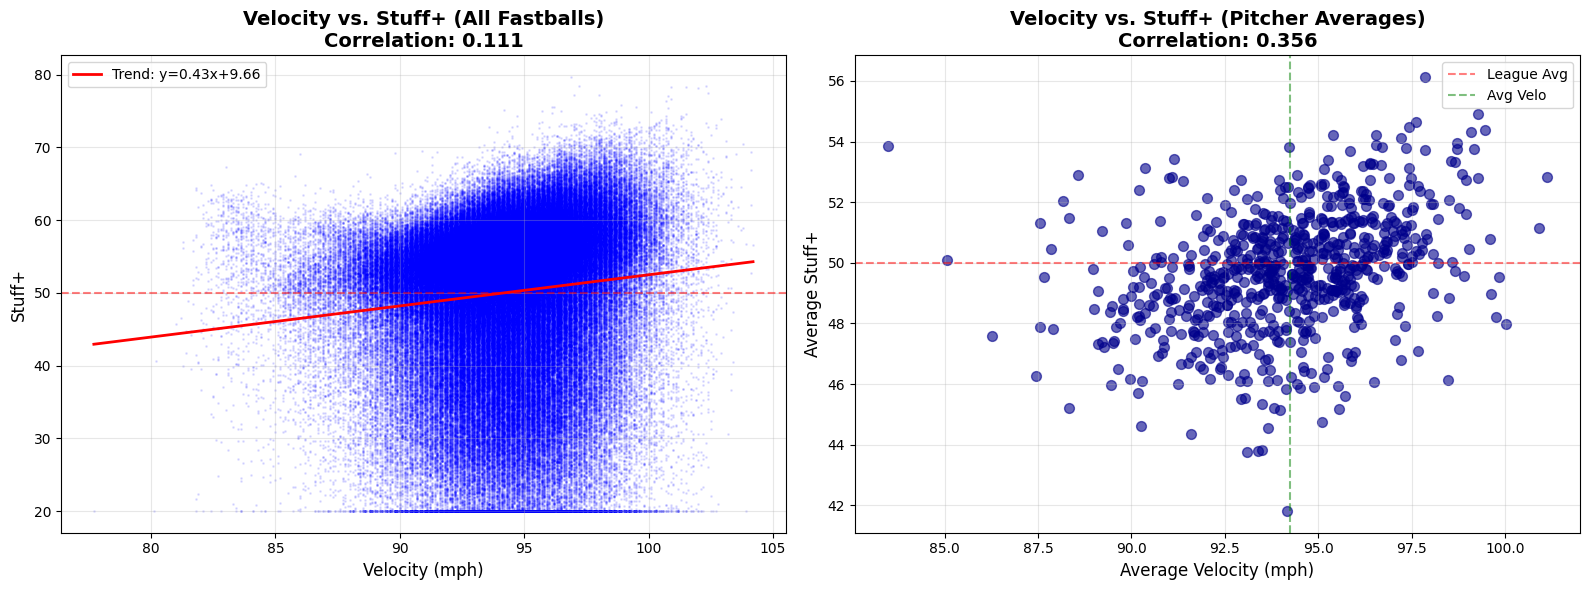


CRAFTY PITCHERS (High Stuff+ without elite velocity)
(Stuff+ >= 55, Velocity < 95 mph)

Empty DataFrame
Columns: [player_name, avg_stuff_plus, avg_velocity, pitches]
Index: []

POWER PITCHERS (Elite velocity + Elite stuff)
(Stuff+ >= 55, Velocity >= 97 mph)

      player_name  avg_stuff_plus  avg_velocity  pitches
Estrada, Jeremiah       56.130042     97.855915      710


In [19]:
## 2. Velocity vs. Stuff+ Analysis

print("=" * 80)
print("VELOCITY vs. STUFF+ ANALYSIS - 2025")
print("=" * 80)
print()

# Analyze fastballs (FF and SI) - velocity matters most for these
fastball_types = ['FF', 'SI']
fastball_data = data_2025[data_2025['pitch_type'].isin(fastball_types)].copy()

if len(fastball_data) > 0:
    # Calculate correlation
    correlation = fastball_data['release_speed'].corr(fastball_data['stuff_plus'])
    print(f"Correlation between velocity and Stuff+ (Fastballs): {correlation:.3f}")
    print()

    # Create scatter plot
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Plot 1: All fastballs
    axes[0].scatter(fastball_data['release_speed'], fastball_data['stuff_plus'],
                    alpha=0.1, s=1, c='blue')
    axes[0].set_xlabel('Velocity (mph)', fontsize=12)
    axes[0].set_ylabel('Stuff+', fontsize=12)
    axes[0].set_title(f'Velocity vs. Stuff+ (All Fastballs)\nCorrelation: {correlation:.3f}',
                      fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    axes[0].axhline(50, color='red', linestyle='--', alpha=0.5)

    # Add trend line
    z = np.polyfit(fastball_data['release_speed'], fastball_data['stuff_plus'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(fastball_data['release_speed'].min(),
                         fastball_data['release_speed'].max(), 100)
    axes[0].plot(x_line, p(x_line), "r-", linewidth=2, label=f'Trend: y={z[0]:.2f}x+{z[1]:.2f}')
    axes[0].legend()

    # Plot 2: Pitcher-level averages
    pitcher_velo = fastball_data.groupby(['pitcher', 'player_name']).agg(
        avg_velocity=('release_speed', 'mean'),
        avg_stuff_plus=('stuff_plus', 'mean'),
        pitches=('stuff_plus', 'count')
    ).reset_index()

    pitcher_velo = pitcher_velo[pitcher_velo['pitches'] >= 50]

    axes[1].scatter(pitcher_velo['avg_velocity'], pitcher_velo['avg_stuff_plus'],
                    alpha=0.6, s=50, c='darkblue')
    axes[1].set_xlabel('Average Velocity (mph)', fontsize=12)
    axes[1].set_ylabel('Average Stuff+', fontsize=12)

    pitcher_corr = pitcher_velo['avg_velocity'].corr(pitcher_velo['avg_stuff_plus'])
    axes[1].set_title(f'Velocity vs. Stuff+ (Pitcher Averages)\nCorrelation: {pitcher_corr:.3f}',
                      fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    axes[1].axhline(50, color='red', linestyle='--', alpha=0.5, label='League Avg')
    axes[1].axvline(fastball_data['release_speed'].mean(), color='green',
                    linestyle='--', alpha=0.5, label='Avg Velo')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # Elite stuff without elite velocity (crafty pitchers)
    print("\n" + "=" * 80)
    print("CRAFTY PITCHERS (High Stuff+ without elite velocity)")
    print("=" * 80)
    print("(Stuff+ >= 55, Velocity < 95 mph)")
    print()

    crafty = pitcher_velo[
        (pitcher_velo['avg_stuff_plus'] >= 55) &
        (pitcher_velo['avg_velocity'] < 95)
    ].sort_values('avg_stuff_plus', ascending=False).head(15)

    print(crafty[['player_name', 'avg_stuff_plus', 'avg_velocity', 'pitches']].to_string(index=False))

    # Hard throwers with elite stuff
    print("\n" + "=" * 80)
    print("POWER PITCHERS (Elite velocity + Elite stuff)")
    print("=" * 80)
    print("(Stuff+ >= 55, Velocity >= 97 mph)")
    print()

    power = pitcher_velo[
        (pitcher_velo['avg_stuff_plus'] >= 55) &
        (pitcher_velo['avg_velocity'] >= 97)
    ].sort_values('avg_stuff_plus', ascending=False).head(15)

    print(power[['player_name', 'avg_stuff_plus', 'avg_velocity', 'pitches']].to_string(index=False))
else:
    print("No fastball data available")

SPIN RATE vs. STUFF+ ANALYSIS - 2025



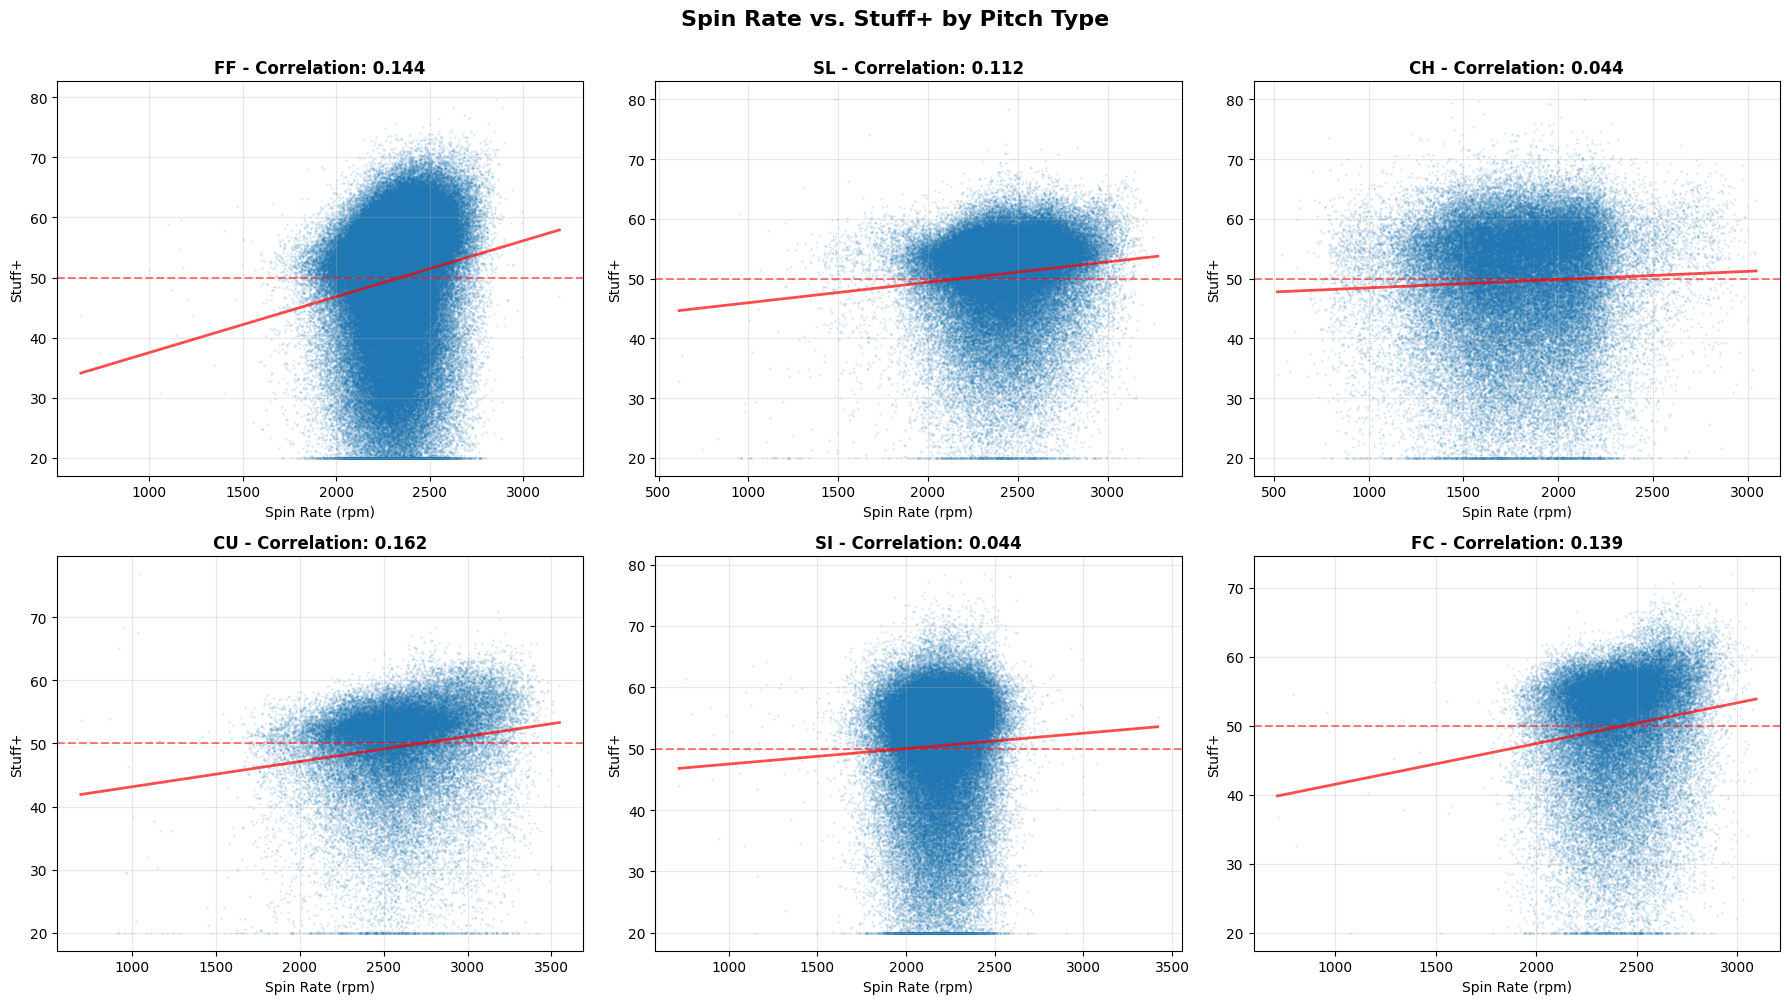


HIGH-SPIN MASTERS (Top spin rates with elite stuff)


Top 10 Fastball Spin Rates (with Stuff+ >= 52):
     player_name    avg_spin  avg_stuff_plus  pitches
Hollowell, Gavin 2717.519481       52.911352       77
     Pérez, Eury 2685.918510       53.893411      859
Rodríguez, Randy 2653.460744       53.792686      484
Ribalta, Orlando 2645.497354       53.041318      189
  Pomeranz, Drew 2639.982732       52.390701      637
  Snider, Collin 2621.341085       52.149809      129
  Stewart, Brock 2620.049689       53.932957      322
   Pagán, Emilio 2611.840841       52.509598      666
    Burns, Chase 2604.954751       54.101187      442
    García, Yimi 2590.923977       52.770373      171

Top 10 Slider Spin Rates (with Stuff+ >= 52):
     player_name    avg_spin  avg_stuff_plus  pitches
     Brash, Matt 2949.836735       55.207487      490
Ashcraft, Graham 2948.308489       54.891954      483
    Abreu, Bryan 2921.545455       52.021940      583
Núñez, Eduarniel 2905.545455       52.43

In [20]:
## 3. Spin Rate Analysis

print("=" * 80)
print("SPIN RATE vs. STUFF+ ANALYSIS - 2025")
print("=" * 80)
print()

# Analyze spin rate by pitch type
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

pitch_types_spin = ['FF', 'SL', 'CH', 'CU', 'SI', 'FC']

for idx, pt in enumerate(pitch_types_spin):
    pt_data = data_2025[data_2025['pitch_type'] == pt].copy()

    if len(pt_data) > 0:
        correlation = pt_data['release_spin_rate'].corr(pt_data['stuff_plus'])

        axes[idx].scatter(pt_data['release_spin_rate'], pt_data['stuff_plus'],
                         alpha=0.1, s=1)
        axes[idx].set_xlabel('Spin Rate (rpm)', fontsize=10)
        axes[idx].set_ylabel('Stuff+', fontsize=10)
        axes[idx].set_title(f'{pt} - Correlation: {correlation:.3f}', fontsize=12, fontweight='bold')
        axes[idx].grid(True, alpha=0.3)
        axes[idx].axhline(50, color='red', linestyle='--', alpha=0.5)

        # Add trend line
        z = np.polyfit(pt_data['release_spin_rate'], pt_data['stuff_plus'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(pt_data['release_spin_rate'].min(),
                            pt_data['release_spin_rate'].max(), 100)
        axes[idx].plot(x_line, p(x_line), "r-", linewidth=2, alpha=0.7)

plt.suptitle('Spin Rate vs. Stuff+ by Pitch Type', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# High-spin masters
print("\n" + "=" * 80)
print("HIGH-SPIN MASTERS (Top spin rates with elite stuff)")
print("=" * 80)
print()

for pt in ['FF', 'SL', 'CU']:
    pt_data = data_2025[data_2025['pitch_type'] == pt].copy()

    if len(pt_data) > 0:
        pitcher_spin = pt_data.groupby(['pitcher', 'player_name']).agg(
            avg_spin=('release_spin_rate', 'mean'),
            avg_stuff_plus=('stuff_plus', 'mean'),
            pitches=('stuff_plus', 'count')
        ).reset_index()

        pitcher_spin = pitcher_spin[pitcher_spin['pitches'] >= 50]

        # Top spin rate with good stuff
        high_spin = pitcher_spin[
            pitcher_spin['avg_stuff_plus'] >= 52
        ].sort_values('avg_spin', ascending=False).head(10)

        pitch_name = {'FF': 'Fastball', 'SL': 'Slider', 'CU': 'Curveball'}
        print(f"\nTop 10 {pitch_name[pt]} Spin Rates (with Stuff+ >= 52):")
        print(high_spin[['player_name', 'avg_spin', 'avg_stuff_plus', 'pitches']].to_string(index=False))

# Low-spin effectiveness (pitchers who succeed without high spin)
print("\n" + "=" * 80)
print("LOW-SPIN EFFECTIVENESS (Elite stuff with below-average spin)")
print("=" * 80)
print()

for pt in ['FF', 'SI']:
    pt_data = data_2025[data_2025['pitch_type'] == pt].copy()

    if len(pt_data) > 0:
        median_spin = pt_data['release_spin_rate'].median()

        pitcher_spin = pt_data.groupby(['pitcher', 'player_name']).agg(
            avg_spin=('release_spin_rate', 'mean'),
            avg_stuff_plus=('stuff_plus', 'mean'),
            pitches=('stuff_plus', 'count')
        ).reset_index()

        pitcher_spin = pitcher_spin[pitcher_spin['pitches'] >= 50]

        # Low spin but elite stuff
        low_spin = pitcher_spin[
            (pitcher_spin['avg_spin'] < median_spin) &
            (pitcher_spin['avg_stuff_plus'] >= 55)
        ].sort_values('avg_stuff_plus', ascending=False).head(10)

        pitch_name = {'FF': 'Fastball', 'SI': 'Sinker'}
        print(f"\n{pitch_name[pt]} - Below-median spin ({median_spin:.0f} rpm) with Stuff+ >= 55:")
        if len(low_spin) > 0:
            print(low_spin[['player_name', 'avg_spin', 'avg_stuff_plus', 'pitches']].to_string(index=False))
        else:
            print("No pitchers meet criteria")

HANDEDNESS ANALYSIS - 2025

PITCHER HANDEDNESS COMPARISON
--------------------------------------------------------------------------------
          avg_stuff_plus  median_stuff_plus  pitches
p_throws                                            
R              50.197197          52.665718   528731
L              49.855786          52.337537   197251


PLATOON SPLITS (vs Same-Handed vs Opposite-Handed Batters)



/tmp/ipykernel_3137/1445521820.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hand_comparison = data_2025.groupby('p_throws').agg(


Right-Handed Pitchers:
  vs RHB (same): Avg Stuff+ = 50.51 (265,701 pitches)
  vs LHB (opp):  Avg Stuff+ = 49.88 (263,030 pitches)

Left-Handed Pitchers:
  vs LHB (same): Avg Stuff+ = 50.85 (60,266 pitches)
  vs RHB (opp):  Avg Stuff+ = 49.42 (136,985 pitches)

BEST SAME-HANDED MATCHUP PITCHES


RHP vs RHB - Best Fastballs:
           player_name  avg_stuff_plus  pitches
     Estrada, Jeremiah       57.401182      403
       López, Reynaldo       56.735900       30
      Henriquez, Ronny       55.781883      198
      Ribalta, Orlando       55.425527       78
Schwellenbach, Spencer       55.424408      214

RHP vs RHB - Best Sliders:
    player_name  avg_stuff_plus  pitches
  Helsley, Ryan       56.619124      272
  Peguero, Joel       56.163973       71
Fisher, Braydon       55.702697      252
  deGrom, Jacob       55.685087      610
     Boyle, Joe       54.981677      165

RHP vs RHB - Best Changeups:
     player_name  avg_stuff_plus  pitches
 Williams, Devin       55.625793      35

/tmp/ipykernel_3137/1445521820.py:77: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rhp_splits = rhp_data.groupby(['pitch_type', 'stand']).agg(
/tmp/ipykernel_3137/1445521820.py:93: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lhp_splits = lhp_data.groupby(['pitch_type', 'stand']).agg(


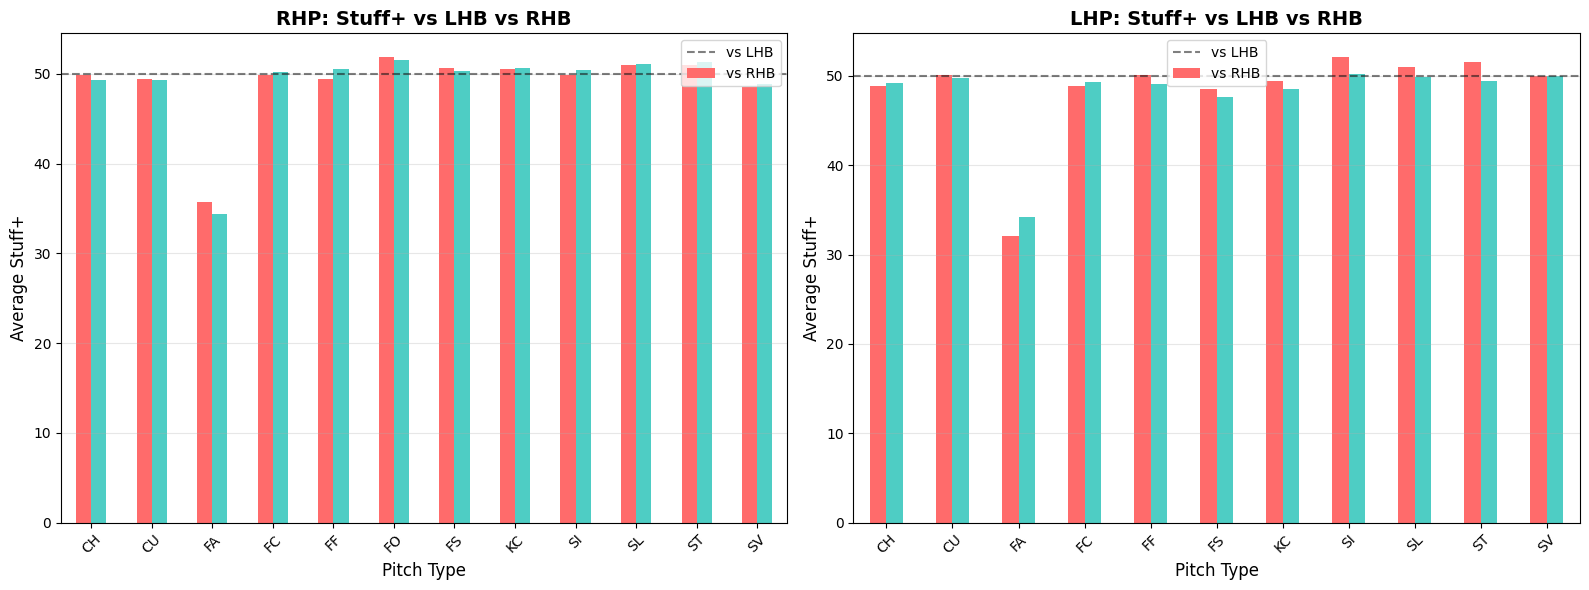

In [21]:
## 4. Handedness Splits Analysis

print("=" * 80)
print("HANDEDNESS ANALYSIS - 2025")
print("=" * 80)
print()

# Overall RHP vs LHP
print("PITCHER HANDEDNESS COMPARISON")
print("-" * 80)
hand_comparison = data_2025.groupby('p_throws').agg(
    avg_stuff_plus=('stuff_plus', 'mean'),
    median_stuff_plus=('stuff_plus', 'median'),
    pitches=('stuff_plus', 'count')
)
print(hand_comparison)
print()

# Platoon advantage analysis (same-handed matchups)
print("\n" + "=" * 80)
print("PLATOON SPLITS (vs Same-Handed vs Opposite-Handed Batters)")
print("=" * 80)
print()

# RHP vs RHB (same) and RHP vs LHB (opposite)
rhp_vs_rhb = data_2025[(data_2025['p_throws'] == 'R') & (data_2025['stand'] == 'R')]
rhp_vs_lhb = data_2025[(data_2025['p_throws'] == 'R') & (data_2025['stand'] == 'L')]

# LHP vs LHB (same) and LHP vs RHB (opposite)
lhp_vs_lhb = data_2025[(data_2025['p_throws'] == 'L') & (data_2025['stand'] == 'L')]
lhp_vs_rhb = data_2025[(data_2025['p_throws'] == 'L') & (data_2025['stand'] == 'R')]

print("Right-Handed Pitchers:")
print(f"  vs RHB (same): Avg Stuff+ = {rhp_vs_rhb['stuff_plus'].mean():.2f} ({len(rhp_vs_rhb):,} pitches)")
print(f"  vs LHB (opp):  Avg Stuff+ = {rhp_vs_lhb['stuff_plus'].mean():.2f} ({len(rhp_vs_lhb):,} pitches)")
print()
print("Left-Handed Pitchers:")
print(f"  vs LHB (same): Avg Stuff+ = {lhp_vs_lhb['stuff_plus'].mean():.2f} ({len(lhp_vs_lhb):,} pitches)")
print(f"  vs RHB (opp):  Avg Stuff+ = {lhp_vs_rhb['stuff_plus'].mean():.2f} ({len(lhp_vs_rhb):,} pitches)")

# Best same-handed matchup pitches by type
print("\n" + "=" * 80)
print("BEST SAME-HANDED MATCHUP PITCHES")
print("=" * 80)
print()

for pt in ['FF', 'SL', 'CH', 'CU']:
    # RHP vs RHB
    rhp_same = data_2025[
        (data_2025['p_throws'] == 'R') &
        (data_2025['stand'] == 'R') &
        (data_2025['pitch_type'] == pt)
    ]

    if len(rhp_same) > 0:
        rhp_same_leaders = rhp_same.groupby(['pitcher', 'player_name']).agg(
            avg_stuff_plus=('stuff_plus', 'mean'),
            pitches=('stuff_plus', 'count')
        ).reset_index()

        rhp_same_leaders = rhp_same_leaders[rhp_same_leaders['pitches'] >= 30]
        rhp_same_leaders = rhp_same_leaders.sort_values('avg_stuff_plus', ascending=False).head(5)

        pitch_name = {'FF': 'Fastball', 'SL': 'Slider', 'CH': 'Changeup', 'CU': 'Curveball'}
        print(f"\nRHP vs RHB - Best {pitch_name[pt]}s:")
        print(rhp_same_leaders[['player_name', 'avg_stuff_plus', 'pitches']].to_string(index=False))

# Visualize platoon splits by pitch type
print("\n" + "=" * 80)
print("PLATOON SPLITS BY PITCH TYPE")
print("=" * 80)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# RHP splits
rhp_data = data_2025[data_2025['p_throws'] == 'R']
rhp_splits = rhp_data.groupby(['pitch_type', 'stand']).agg(
    avg_stuff_plus=('stuff_plus', 'mean')
).reset_index()

rhp_pivot = rhp_splits.pivot(index='pitch_type', columns='stand', values='avg_stuff_plus')
rhp_pivot.plot(kind='bar', ax=ax1, color=['#FF6B6B', '#4ECDC4'])
ax1.set_title('RHP: Stuff+ vs LHB vs RHB', fontsize=14, fontweight='bold')
ax1.set_xlabel('Pitch Type', fontsize=12)
ax1.set_ylabel('Average Stuff+', fontsize=12)
ax1.axhline(50, color='black', linestyle='--', alpha=0.5)
ax1.legend(['vs LHB', 'vs RHB'])
ax1.grid(axis='y', alpha=0.3)
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

# LHP splits
lhp_data = data_2025[data_2025['p_throws'] == 'L']
lhp_splits = lhp_data.groupby(['pitch_type', 'stand']).agg(
    avg_stuff_plus=('stuff_plus', 'mean')
).reset_index()

lhp_pivot = lhp_splits.pivot(index='pitch_type', columns='stand', values='avg_stuff_plus')
lhp_pivot.plot(kind='bar', ax=ax2, color=['#FF6B6B', '#4ECDC4'])
ax2.set_title('LHP: Stuff+ vs LHB vs RHB', fontsize=14, fontweight='bold')
ax2.set_xlabel('Pitch Type', fontsize=12)
ax2.set_ylabel('Average Stuff+', fontsize=12)
ax2.axhline(50, color='black', linestyle='--', alpha=0.5)
ax2.legend(['vs LHB', 'vs RHB'])
ax2.grid(axis='y', alpha=0.3)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

STUFF+ CONSISTENCY ANALYSIS - 2025

Measuring game-to-game variability in Stuff+

MOST CONSISTENT PITCHERS (Low game-to-game variance)
(Minimum 5 games, sorted by lowest standard deviation)

     player_name  mean_stuff_plus  std_stuff_plus  games  total_pitches
Javier, Cristian        48.576248        0.343677      8            617
  Barnett, Mason        51.001979        0.568111      5            431
  Peralta, Sammy        50.330245        0.574583      5            153
   Feltner, Ryan        48.024796        0.612446      7            597
    Evans, Logan        48.040542        0.615959     17           1399
  Quintana, Jose        47.703403        0.669557     24           2174
Springs, Jeffrey        48.410648        0.733899     32           2847
 Alvarez, Andrew        48.903661        0.759240      5            414
 Lawrence, Casey        48.169970        0.766066      5            268
   Pérez, Martín        47.289380        0.776611     12            961
     Ortiz, Luis 

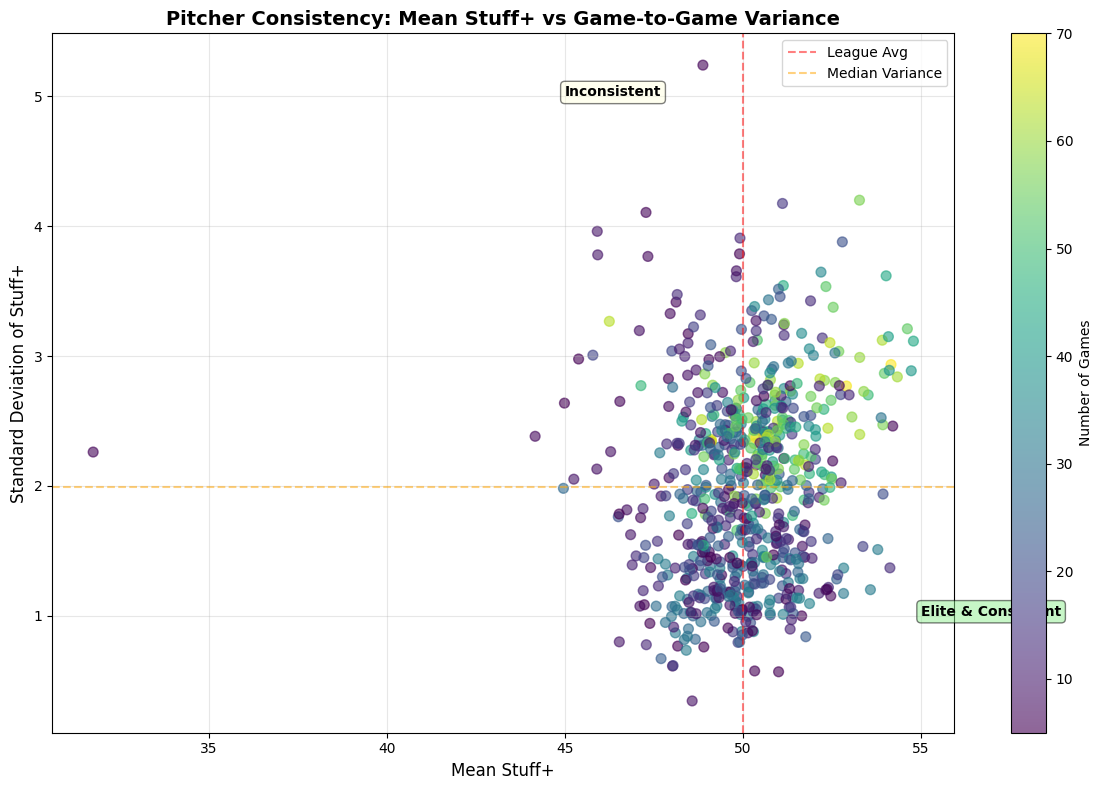

In [22]:
## 5. Stuff+ Consistency Analysis

print("=" * 80)
print("STUFF+ CONSISTENCY ANALYSIS - 2025")
print("=" * 80)
print()
print("Measuring game-to-game variability in Stuff+")
print()

# Calculate game-by-game Stuff+ for each pitcher
pitcher_game_stats = data_2025.groupby(['pitcher', 'player_name', 'game_date']).agg(
    avg_stuff_plus=('stuff_plus', 'mean'),
    pitches=('stuff_plus', 'count')
).reset_index()

# Filter for games with at least 10 pitches
pitcher_game_stats = pitcher_game_stats[pitcher_game_stats['pitches'] >= 10]

# Calculate consistency metrics per pitcher
consistency_stats = pitcher_game_stats.groupby(['pitcher', 'player_name']).agg(
    mean_stuff_plus=('avg_stuff_plus', 'mean'),
    std_stuff_plus=('avg_stuff_plus', 'std'),
    games=('game_date', 'count'),
    total_pitches=('pitches', 'sum')
).reset_index()

# Filter for pitchers with 5+ games
consistency_stats = consistency_stats[consistency_stats['games'] >= 5]

# Calculate coefficient of variation (lower = more consistent)
consistency_stats['cv'] = consistency_stats['std_stuff_plus'] / consistency_stats['mean_stuff_plus']
consistency_stats['consistency_score'] = 100 - (consistency_stats['cv'] * 100)

# Most consistent pitchers (low std dev, high mean)
print("=" * 80)
print("MOST CONSISTENT PITCHERS (Low game-to-game variance)")
print("=" * 80)
print("(Minimum 5 games, sorted by lowest standard deviation)")
print()

most_consistent = consistency_stats.sort_values('std_stuff_plus').head(20)
print(most_consistent[['player_name', 'mean_stuff_plus', 'std_stuff_plus', 'games', 'total_pitches']].to_string(index=False))

# Least consistent pitchers (high variance)
print("\n" + "=" * 80)
print("MOST VOLATILE PITCHERS (High game-to-game variance)")
print("=" * 80)
print("(Minimum 5 games, sorted by highest standard deviation)")
print()

least_consistent = consistency_stats.sort_values('std_stuff_plus', ascending=False).head(20)
print(least_consistent[['player_name', 'mean_stuff_plus', 'std_stuff_plus', 'games', 'total_pitches']].to_string(index=False))

# Consistent elite pitchers (high mean + low variance)
print("\n" + "=" * 80)
print("CONSISTENTLY ELITE PITCHERS")
print("=" * 80)
print("(Mean Stuff+ >= 52, Std Dev < 3.0)")
print()

elite_consistent = consistency_stats[
    (consistency_stats['mean_stuff_plus'] >= 52) &
    (consistency_stats['std_stuff_plus'] < 3.0)
].sort_values('mean_stuff_plus', ascending=False).head(15)

print(elite_consistent[['player_name', 'mean_stuff_plus', 'std_stuff_plus', 'games']].to_string(index=False))

# Visualization: Mean vs Std Dev
fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(consistency_stats['mean_stuff_plus'],
                     consistency_stats['std_stuff_plus'],
                     alpha=0.6, s=50, c=consistency_stats['games'],
                     cmap='viridis')

ax.set_xlabel('Mean Stuff+', fontsize=12)
ax.set_ylabel('Standard Deviation of Stuff+', fontsize=12)
ax.set_title('Pitcher Consistency: Mean Stuff+ vs Game-to-Game Variance',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.axvline(50, color='red', linestyle='--', alpha=0.5, label='League Avg')
ax.axhline(consistency_stats['std_stuff_plus'].median(), color='orange',
           linestyle='--', alpha=0.5, label='Median Variance')

# Add quadrant labels
ax.text(55, 1, 'Elite & Consistent', fontsize=10, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
ax.text(45, 5, 'Inconsistent', fontsize=10, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Number of Games', fontsize=10)
ax.legend()

plt.tight_layout()
plt.show()

STUFF+ vs. USAGE ANALYSIS - 2025

Do pitchers throw their best pitches more often?

Correlation between Stuff+ and Usage%: 0.304



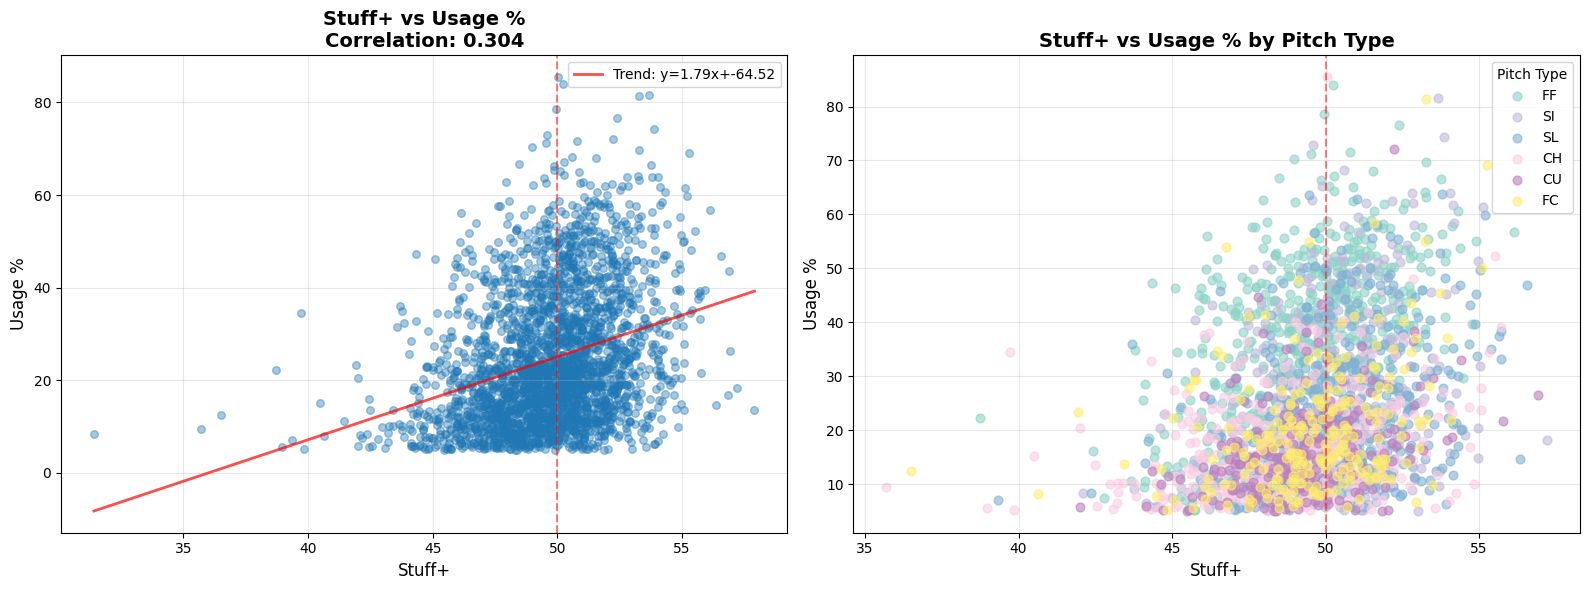


UNDERUTILIZED ELITE PITCHES
(Stuff+ >= 58, Usage < 20%)

Empty DataFrame
Columns: [player_name, pitch_type, avg_stuff_plus, usage_pct, pitch_count, total_pitches]
Index: []

OVER-RELIED PITCHES
(Stuff+ < 48, Usage > 30%)

       player_name pitch_type  avg_stuff_plus  usage_pct  pitch_count  total_pitches
      Sasaki, Roki         FF       47.952290  62.753036          310            494
    Kowar, Jackson         FF       47.698110  57.651246          162            281
Senzatela, Antonio         FF       47.606201  57.648546         1368           2373
     Rashi, Taylor         FF       46.152362  56.011730          191            341
       Dodd, Dylan         FC       46.749119  53.917910          289            536
   Halvorsen, Seth         FF       47.976276  53.822630          352            654
     Anderson, Ian         FF       46.471342  51.724138          105            203
      Brubaker, JT         SI       47.631242  49.893390          234            469
     Farris,

/tmp/ipykernel_3137/1057446516.py:132: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tier_usage = pitcher_usage.groupby('stuff_tier').agg(


In [23]:
## 6. Stuff+ vs. Usage Analysis

print("=" * 80)
print("STUFF+ vs. USAGE ANALYSIS - 2025")
print("=" * 80)
print()
print("Do pitchers throw their best pitches more often?")
print()

# Calculate usage percentage for each pitcher-pitch combination
pitcher_usage = data_2025.groupby(['pitcher', 'player_name', 'pitch_type']).agg(
    pitch_count=('pitch_type', 'count'),
    avg_stuff_plus=('stuff_plus', 'mean')
).reset_index()

# Get total pitches per pitcher
pitcher_totals = data_2025.groupby('pitcher').size().reset_index(name='total_pitches')

# Merge and calculate usage percentage
pitcher_usage = pitcher_usage.merge(pitcher_totals, on='pitcher')
pitcher_usage['usage_pct'] = (pitcher_usage['pitch_count'] / pitcher_usage['total_pitches']) * 100

# Filter for pitchers with 200+ total pitches
pitcher_usage = pitcher_usage[pitcher_usage['total_pitches'] >= 200]

# Filter for pitches used at least 5% of the time
pitcher_usage = pitcher_usage[pitcher_usage['usage_pct'] >= 5.0]

# Calculate correlation
correlation = pitcher_usage['avg_stuff_plus'].corr(pitcher_usage['usage_pct'])
print(f"Correlation between Stuff+ and Usage%: {correlation:.3f}")
print()

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Overall scatter
axes[0].scatter(pitcher_usage['avg_stuff_plus'], pitcher_usage['usage_pct'],
                alpha=0.4, s=30)
axes[0].set_xlabel('Stuff+', fontsize=12)
axes[0].set_ylabel('Usage %', fontsize=12)
axes[0].set_title(f'Stuff+ vs Usage %\nCorrelation: {correlation:.3f}',
                  fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].axvline(50, color='red', linestyle='--', alpha=0.5)

# Add trend line
z = np.polyfit(pitcher_usage['avg_stuff_plus'], pitcher_usage['usage_pct'], 1)
p = np.poly1d(z)
x_line = np.linspace(pitcher_usage['avg_stuff_plus'].min(),
                     pitcher_usage['avg_stuff_plus'].max(), 100)
axes[0].plot(x_line, p(x_line), "r-", linewidth=2, alpha=0.7,
             label=f'Trend: y={z[0]:.2f}x+{z[1]:.2f}')
axes[0].legend()

# Plot 2: By pitch type
pitch_types_usage = ['FF', 'SI', 'SL', 'CH', 'CU', 'FC']
colors = plt.cm.Set3(np.linspace(0, 1, len(pitch_types_usage)))

for idx, pt in enumerate(pitch_types_usage):
    pt_data = pitcher_usage[pitcher_usage['pitch_type'] == pt]
    if len(pt_data) > 0:
        axes[1].scatter(pt_data['avg_stuff_plus'], pt_data['usage_pct'],
                       alpha=0.6, s=40, label=pt, color=colors[idx])

axes[1].set_xlabel('Stuff+', fontsize=12)
axes[1].set_ylabel('Usage %', fontsize=12)
axes[1].set_title('Stuff+ vs Usage % by Pitch Type', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].axvline(50, color='red', linestyle='--', alpha=0.5)
axes[1].legend(title='Pitch Type', loc='best')

plt.tight_layout()
plt.show()

# Underutilized elite pitches
print("\n" + "=" * 80)
print("UNDERUTILIZED ELITE PITCHES")
print("=" * 80)
print("(Stuff+ >= 58, Usage < 20%)")
print()

underutilized = pitcher_usage[
    (pitcher_usage['avg_stuff_plus'] >= 58) &
    (pitcher_usage['usage_pct'] < 20)
].sort_values('avg_stuff_plus', ascending=False).head(20)

print(underutilized[['player_name', 'pitch_type', 'avg_stuff_plus', 'usage_pct',
                     'pitch_count', 'total_pitches']].to_string(index=False))

# Over-relied pitches (high usage, below average stuff)
print("\n" + "=" * 80)
print("OVER-RELIED PITCHES")
print("=" * 80)
print("(Stuff+ < 48, Usage > 30%)")
print()

overrelied = pitcher_usage[
    (pitcher_usage['avg_stuff_plus'] < 48) &
    (pitcher_usage['usage_pct'] > 30)
].sort_values('usage_pct', ascending=False).head(20)

print(overrelied[['player_name', 'pitch_type', 'avg_stuff_plus', 'usage_pct',
                  'pitch_count', 'total_pitches']].to_string(index=False))

# Optimal usage (high stuff, high usage)
print("\n" + "=" * 80)
print("OPTIMAL USAGE")
print("=" * 80)
print("(Stuff+ >= 58, Usage >= 30%)")
print()

optimal = pitcher_usage[
    (pitcher_usage['avg_stuff_plus'] >= 58) &
    (pitcher_usage['usage_pct'] >= 30)
].sort_values('avg_stuff_plus', ascending=False).head(15)

print(optimal[['player_name', 'pitch_type', 'avg_stuff_plus', 'usage_pct',
               'pitch_count']].to_string(index=False))

# Usage breakdown by stuff tier
print("\n" + "=" * 80)
print("AVERAGE USAGE BY STUFF+ TIER")
print("=" * 80)

pitcher_usage['stuff_tier'] = pd.cut(pitcher_usage['avg_stuff_plus'],
                                      bins=[0, 45, 50, 55, 60, 100],
                                      labels=['Poor (<45)', 'Below Avg (45-50)',
                                             'Above Avg (50-55)', 'Plus (55-60)',
                                             'Elite (60+)'])

tier_usage = pitcher_usage.groupby('stuff_tier').agg(
    avg_usage=('usage_pct', 'mean'),
    median_usage=('usage_pct', 'median'),
    count=('usage_pct', 'count')
)

print(tier_usage)

In [24]:
## Summary Statistics

print("=" * 80)
print("2025 STUFF+ ANALYSIS SUMMARY")
print("=" * 80)
print()
print(f"Total pitches analyzed: {len(data_2025):,}")
print(f"Overall Stuff+ mean: {data_2025['stuff_plus'].mean():.2f}")
print(f"Overall Stuff+ std: {data_2025['stuff_plus'].std():.2f}")
print()
print("By Role:")
role_summary = data_2025.groupby('role').agg(
    avg_stuff_plus=('stuff_plus', 'mean'),
    pitches=('stuff_plus', 'count')
)
print(role_summary)
print()
print("By Pitch Type:")
pitch_type_summary = data_2025.groupby('pitch_type').agg(
    avg_stuff_plus=('stuff_plus', 'mean'),
    pitches=('stuff_plus', 'count')
).sort_values('avg_stuff_plus', ascending=False)
print(pitch_type_summary)
print()
print("Leaderboard Coverage:")
print(f"  - Qualified SPs (200+ pitches): {len(sp_leaderboard)}")
print(f"  - Qualified RPs (100+ pitches): {len(rp_leaderboard)}")
print(f"  - Qualified pitch-type combos (50+ pitches): {len(pitch_leaderboard)}")

2025 STUFF+ ANALYSIS SUMMARY

Total pitches analyzed: 725,982
Overall Stuff+ mean: 50.10
Overall Stuff+ std: 9.30

By Role:
      avg_stuff_plus  pitches
role                         
RP         50.323220   316083
SP         49.935724   409899

By Pitch Type:
            avg_stuff_plus  pitches
pitch_type                         
FO               51.755032      541
ST               51.018820    52846
SL               50.846557   107103
SI               50.476848   113588
KC               50.238624    12866
FS               50.216627    23499
FC               49.840060    55256
FF               49.800139   232018
CH               49.527893    74773
CU               49.498130    48966
SV               49.095786     3630
FA               34.821941      896

Leaderboard Coverage:
  - Qualified SPs (200+ pitches): 235
  - Qualified RPs (100+ pitches): 489
  - Qualified pitch-type combos (50+ pitches): 2562
